In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import normflows as nf
from tqdm import tqdm

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.dirname(c_directory))

import architecture
import DCD_simulator
import eZplot

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


DCD_simulator.adjust_device(device)

seed=42
torch.manual_seed(seed)

In [2]:
model_file = 'network.pt'
model = architecture.make_model(context_size=1,tail_bound=10)
model.load_state_dict(torch.load(model_file))

/tmp/ipykernel_42709/2419538697.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file))


<All keys matched successfully>

In [3]:
# Define target
target = DCD_simulator.target()
context_size = 1

In [4]:
gt = target.lbeta_dist.sample((1,))
gt

tensor([7.1940], device='cuda:0')

In [5]:
x = target.sample(gt[0],N=2**12)
x = x[:,0].reshape(-1,1)
x

tensor([[7.8709],
        [7.3464],
        [7.6537],
        ...,
        [7.3515],
        [7.3251],
        [7.5520]], device='cuda:0')

In [6]:
vectorize_params = torch.ones(2,1).to(device)

def log_likelihood(data,params,model):
    global vectorize_params
    if data.size !=  vectorize_params.size(0):
        vectorize_params = torch.ones((data.size(0),1),device=device)
    return model.log_prob(data,params*vectorize_params)

def log_post(data,params,model,lprior):
    return log_likelihood(data,params,model).sum() + lprior(params)


In [7]:
lbeta_range = target.lbeta_dist.loc + target.lbeta_dist.scale*torch.linspace(-3,3,101).to(device)
lbeta_range = gt + target.lbeta_dist.scale*.25*torch.linspace(-1,1,301).to(device)

In [10]:
l10 = torch.log(torch.tensor(10.,device=device))
def plot_post(data,model):
    global lbeta_range

    lbeta_range = (lbeta_range-lbeta_range.mean())*(.75) + lbeta_range.mean()
    th = lbeta_range
    arr = np.array([log_post(data,thi,model,target.log_prior).detach().cpu().numpy() for thi in th])

    ll = arr-arr.max()
    p = np.exp(ll)
    p = p/(p.sum()* ((lbeta_range[1]-lbeta_range[0])).cpu().item())

    #plt.plot(th.cpu(),p)
    #plt.axvline(gt.item(),color='y')
    plt.plot((th/l10).cpu(),p)
    plt.axvline((gt/l10).item(),color='red',label='Ground truth')
    plt.legend()

    plt.xlabel(r'$\log \beta$')
    plt.ylabel(r'Posterior ',fontsize=14)
    plt.title('{:>5} datapoints'.format(data.size(0)))
    #plt.savefig('DCD_network_perfom/post_{}-datapoins_seed{}.png'.format(data.size(0),seed),dpi=99)
    



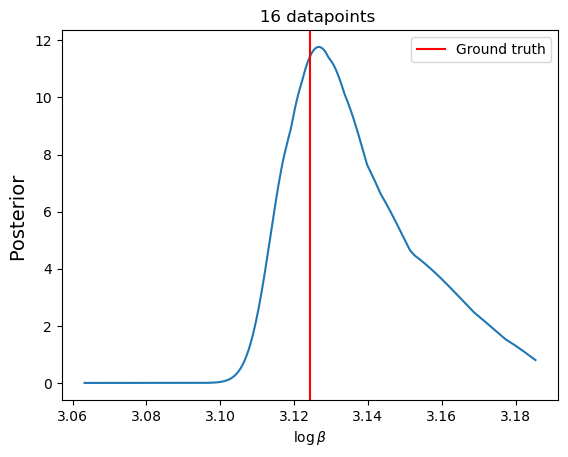

In [11]:

plot_post(x[:16],model)

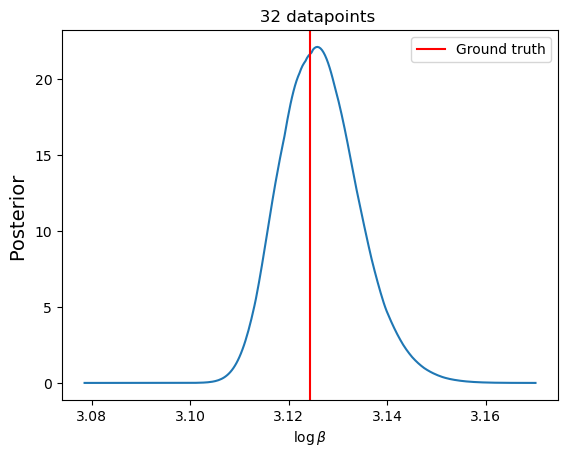

In [12]:
plot_post(x[:32],model)

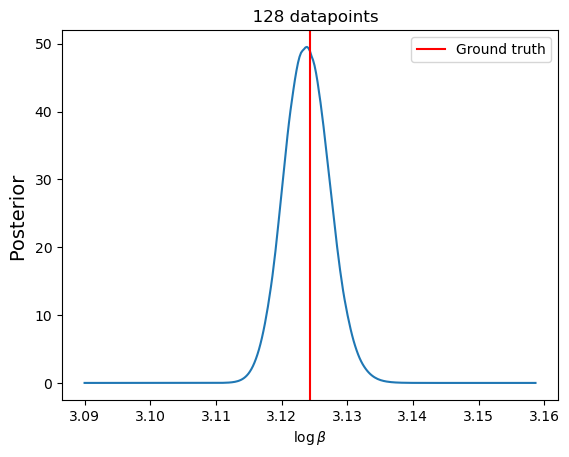

In [13]:
plot_post(x[:128],model)

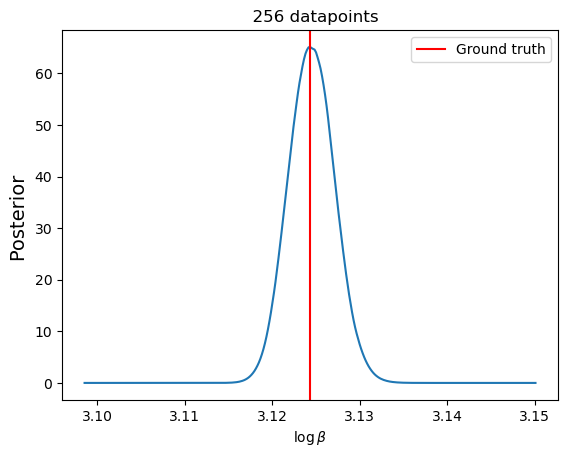

In [14]:
plot_post(x[:256],model)

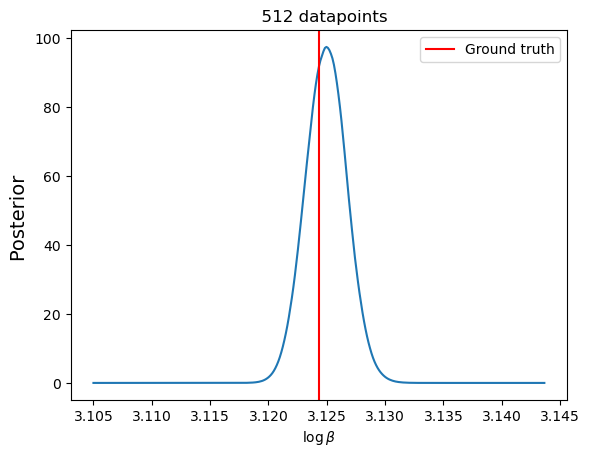

In [15]:
plot_post(x[:512],model)